# Chapter 3: Constructions

**Source Span.** *A Course in Metric Geometry*, Chapter 3, printed pages 59-100, PDF pages 74-115.

The chapter's central question is: **how can new length spaces be built from old ones while keeping the metric honest?** The answer is not a single construction. Local length data can be glued; identifications are enforced by the largest semimetric compatible with the requested zero distances; polyhedra and graphs package gluing combinatorially; quotient maps turn symmetries into spaces; coverings explain when local Euclidean or homogeneous geometry repeats globally; arcwise isometries preserve length while possibly folding; products and cones give analytic formulas for new metrics.

This notebook is a source-grounded reconstruction in computational language. It uses original examples and finite models to expose the mechanisms behind the definitions and theorems, not copied textbook prose or figures.


## Visual Storyboard and Library Routing

| Book construction | Computational model in this notebook | What to inspect |
| --- | --- | --- |
| Locality of intrinsic metrics and the jump metric $d_\varepsilon$ | Shortest paths in a graph of allowed small jumps | Local agreement can hide global disagreement for non-intrinsic metrics. |
| Gluing and maximal metrics | Floyd-Warshall closure of upper bounds, including zero-cost identifications | Triangle inequality forces more distances to shrink than the declared glued pairs. |
| Polyhedral spaces and metric graphs | Labeled graph, face/edge/vertex links, Cayley balls | The metric is controlled by pieces, face identifications, and shortest routes through the 1-skeleton. |
| Isometry quotients and coverings | Orbit graphs and truncated covering diagrams | Free, discontinuous actions give local isometries; fixed points create singular quotient behavior. |
| Arcwise isometries | A pleat map with slopes $\pm 1$ | Length can be preserved even when the map folds and is far from injective. |
| Products and cones | Product metric checks, cone law of cosines, sector/cone surfaces | Product geodesics split into factor geodesics; cone distances truncate base distance at $\pi$. |

**Library Routing.** Matplotlib makes durable 2D metric diagrams; NetworkX represents quotient, covering, and Cayley/metric graphs; NumPy/SciPy-style shortest path closures verify semimetric inequalities; Plotly exports a small interactive product/cone lab as HTML. No shared utilities are modified.


**Visual Storyboard.** The executable sequence is: epsilon-jump locality, maximal semimetric gluing, polyhedral links and word ball, quotient/covering local-isometry diagram, arcwise pleat, and product/cone metric lab. The same plan is written to `visual-storyboard.json` during final sanity so the audit trail is explicit.


In [1]:
from pathlib import Path
import json
import math
import itertools
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon, Arc
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
import networkx as nx
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from IPython.display import HTML, Image, display

BOOK_ROOT = Path.cwd()
for candidate in [BOOK_ROOT, *BOOK_ROOT.parents]:
    if (candidate / "AGENTS.md").exists() and (candidate / "source_map.json").exists():
        BOOK_ROOT = candidate
        break

ART_ROOT = BOOK_ROOT / "artifacts" / "chapter-03"
FIG_DIR = ART_ROOT / "figures"
HTML_DIR = ART_ROOT / "html"
CHECK_DIR = ART_ROOT / "checks"
for folder in [FIG_DIR, HTML_DIR, CHECK_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 150,
    "font.size": 9,
    "axes.titlesize": 11,
    "axes.labelsize": 9,
})


def rel(path):
    return str(Path(path).relative_to(BOOK_ROOT)).replace("\\", "/")


def save_json(path, data):
    path = Path(path)
    path.write_text(json.dumps(data, indent=2, sort_keys=True), encoding="utf-8")
    return path


def display_artifact(path):
    path = Path(path)
    if path.suffix.lower() in {".png", ".jpg", ".jpeg"}:
        display(Image(filename=str(path)))
    elif path.suffix.lower() in {".html", ".htm"}:
        display(HTML(f'<a href="{rel(path)}">{rel(path)}</a>'))
    else:
        display(HTML(f'<code>{rel(path)}</code>'))


def save_matplotlib(fig, path, **kwargs):
    fig.savefig(path, bbox_inches="tight", **kwargs)
    return Path(path)


def save_plotly_html(fig, path, **kwargs):
    fig.write_html(str(path), include_plotlyjs="cdn", full_html=True, **kwargs)
    return Path(path)


def floyd_warshall_matrix(weights):
    dist = np.array(weights, dtype=float)
    n = dist.shape[0]
    for k in range(n):
        dist = np.minimum(dist, dist[:, [k]] + dist[[k], :])
    return dist


def triangle_defects(dist, tol=1e-9):
    n = dist.shape[0]
    defects = []
    for i, j, k in itertools.product(range(n), repeat=3):
        defects.append(dist[i, k] - dist[i, j] - dist[j, k])
    return float(max(defects)), int(sum(d > tol for d in defects))


def image_nonblank(path):
    from PIL import Image as PILImage
    arr = np.asarray(PILImage.open(path).convert("L"))
    return int(arr.max()) > int(arr.min())

checks = {
    "source_span": {
        "chapter": "3 Constructions",
        "printed_pages": "59-100",
        "pdf_pages": "74-115",
        "sections": ["3.1", "3.2", "3.3", "3.4", "3.5", "3.6"],
    },
    "artifacts": {},
    "invariants": {},
}


## 1. Locality: Small Jumps Can Remember More Than Local Distances

An intrinsic metric is determined by local measurements. The chapter contrasts this with general complete metrics by introducing $d_\varepsilon$: travel from $x$ to $y$ by a finite chain of jumps, each original jump no longer than $\varepsilon$, and minimize the sum of original jump lengths.

The model below samples a circle with the **chord metric**, which is complete but not the intrinsic circular metric. For nearby points $d_\varepsilon$ agrees with the chord metric. For far points, small jumps force travel along the circle, so the global distance changes.


In [2]:
N = 64
angles = np.linspace(0, 2 * np.pi, N, endpoint=False)
points = np.column_stack([np.cos(angles), np.sin(angles)])
chord = np.linalg.norm(points[:, None, :] - points[None, :, :], axis=2)
eps = 0.34
jump_weights = np.where(chord <= eps + 1e-12, chord, np.inf)
np.fill_diagonal(jump_weights, 0.0)
d_eps = floyd_warshall_matrix(jump_weights)
local_mask = chord <= eps + 1e-12
antipode = N // 2

fig, axes = plt.subplots(1, 3, figsize=(12, 3.8), constrained_layout=True)
axes[0].plot(points[:, 0], points[:, 1], color="#3b6ea8", lw=1.4)
axes[0].scatter(points[:, 0], points[:, 1], s=8, color="#25364f")
for i in range(0, N, 8):
    j = (i + 1) % N
    axes[0].plot(points[[i, j], 0], points[[i, j], 1], color="#d65f5f", lw=2)
axes[0].set_title(r"allowed jumps: $d \leq \varepsilon$")
axes[0].set_aspect("equal")
axes[0].axis("off")

im0 = axes[1].imshow(chord, cmap="viridis")
axes[1].set_title("original chord distances")
fig.colorbar(im0, ax=axes[1], fraction=0.046)
im1 = axes[2].imshow(d_eps, cmap="magma")
axes[2].set_title(r"$d_\varepsilon$ shortest jump metric")
fig.colorbar(im1, ax=axes[2], fraction=0.046)

locality_path = FIG_DIR / "locality-epsilon-jumps.png"
save_matplotlib(fig, locality_path)
plt.close(fig)

checks["artifacts"]["locality-epsilon-jumps"] = rel(locality_path)
checks["invariants"]["locality_epsilon"] = {
    "epsilon": eps,
    "local_agreement_max_abs_error": float(np.max(np.abs(d_eps[local_mask] - chord[local_mask]))),
    "antipodal_chord_distance": float(chord[0, antipode]),
    "antipodal_jump_distance": float(d_eps[0, antipode]),
    "triangle_max_defect": triangle_defects(d_eps)[0],
}
checks["invariants"]["locality_epsilon"]


{'epsilon': 0.34,
 'local_agreement_max_abs_error': 0.0,
 'antipodal_chord_distance': 2.0,
 'antipodal_jump_distance': 3.130643769766356,
 'triangle_max_defect': 5.551115123125783e-16}

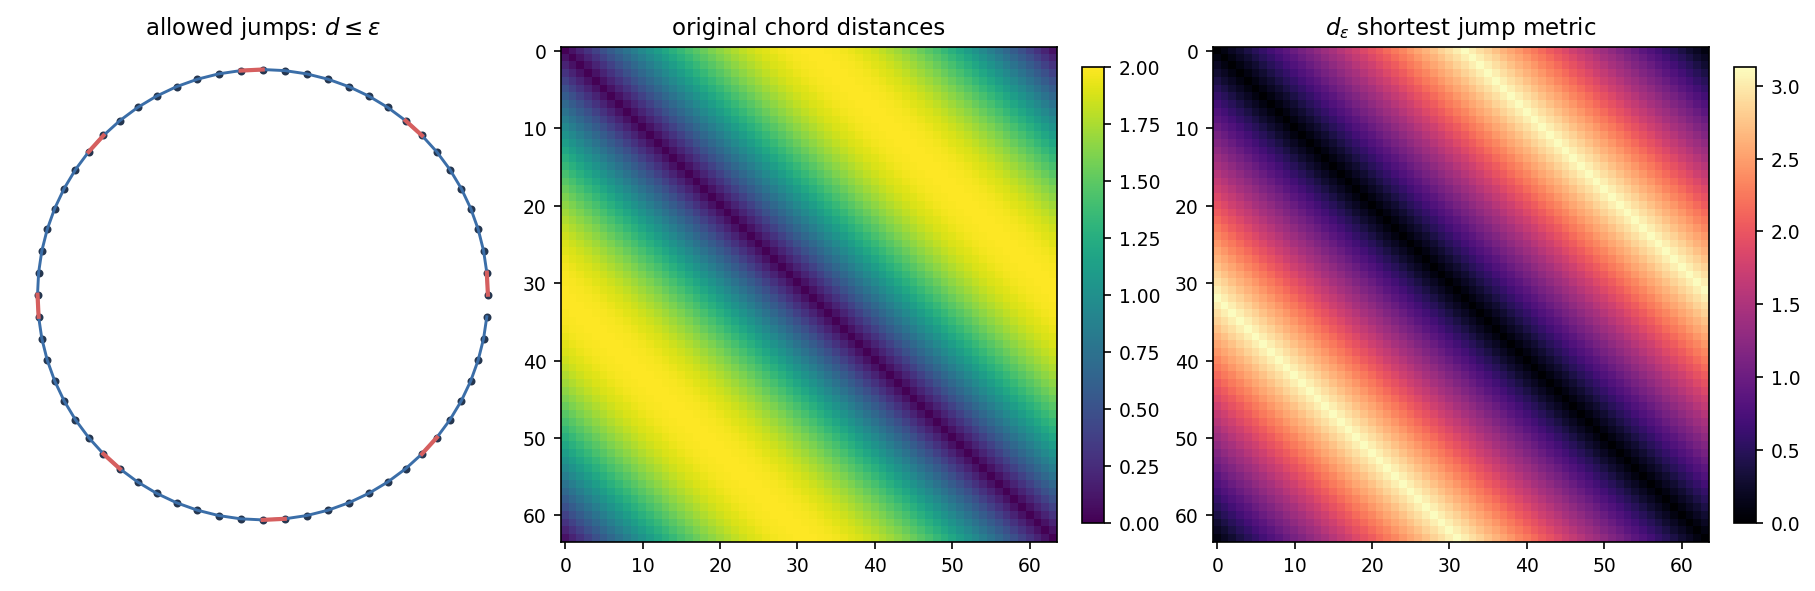

In [3]:
display_artifact(locality_path)


The heatmaps show the key lesson from Section 3.1. A local observer sees no difference when a single allowed jump reaches the target, but the chain metric has a different long-range geometry. This is why locality characterizes intrinsic metrics rather than arbitrary metrics.


## 2. Gluing as the Maximal Semimetric Under Upper Bounds

Metric gluing begins with an equivalence relation, but the triangle inequality decides the final distances. Computationally, the maximal semimetric dominated by upper bounds $b$ is the all-pairs shortest-path closure of those upper bounds: every declared edge is an upper bound, and any polygonal route gives a derived upper bound. The largest semimetric below them is the tightest closure satisfying the triangle inequality.

Here four points lie on a line. We declare $A \sim C$ at zero cost. The pair $B,D$ was not glued, yet its distance shrinks because it can travel through the zero edge.


In [4]:
labels = ["A", "B", "C", "D"]
xpos = np.array([0.0, 1.0, 3.0, 4.2])
original = np.abs(xpos[:, None] - xpos[None, :])
bounds = original.copy()
bounds[0, 2] = bounds[2, 0] = 0.0
quotient = floyd_warshall_matrix(bounds)

fig, axes = plt.subplots(1, 3, figsize=(12.2, 3.4), constrained_layout=True)
for ax, matrix, title in zip(
    axes[:2],
    [original, quotient],
    ["before gluing", "maximal semimetric after $A\sim C$"],
):
    im = ax.imshow(matrix, cmap="YlGnBu", vmin=0, vmax=4.2)
    ax.set_xticks(range(4), labels)
    ax.set_yticks(range(4), labels)
    ax.set_title(title)
    for i in range(4):
        for j in range(4):
            ax.text(j, i, f"{matrix[i,j]:.1f}", ha="center", va="center", fontsize=8)
    fig.colorbar(im, ax=ax, fraction=0.046)

ax = axes[2]
for i, lab in enumerate(labels):
    ax.scatter(xpos[i], 0, s=90, color="#2f5d7c", zorder=3)
    ax.text(xpos[i], 0.16, lab, ha="center", weight="bold")
ax.plot(xpos, np.zeros_like(xpos), color="#8c8c8c", lw=1)
ax.plot([xpos[0], xpos[2]], [0, 0], color="#c84b31", lw=3, ls="--", label="zero identification")
ax.annotate("B reaches D via B-A~C-D", xy=(2.15, -0.05), xytext=(2.15, -0.55),
            arrowprops=dict(arrowstyle="->", color="#333333"), ha="center")
ax.set_ylim(-0.8, 0.55)
ax.set_axis_off()
ax.legend(loc="lower left", frameon=False)

gluing_path = FIG_DIR / "gluing-maximal-semimetric.png"
save_matplotlib(fig, gluing_path)
plt.close(fig)

checks["artifacts"]["gluing-maximal-semimetric"] = rel(gluing_path)
checks["invariants"]["gluing_maximal_semimetric"] = {
    "dR_leq_d": bool(np.all(quotient <= original + 1e-9)),
    "declared_pair_zero": float(quotient[0, 2]),
    "forced_shrink_BD_original": float(original[1, 3]),
    "forced_shrink_BD_quotient": float(quotient[1, 3]),
    "triangle_max_defect": triangle_defects(quotient)[0],
    "triangle_violations": triangle_defects(quotient)[1],
}
checks["invariants"]["gluing_maximal_semimetric"]


<>:12: SyntaxWarning: invalid escape sequence '\s'
<>:12: SyntaxWarning: invalid escape sequence '\s'
C:\Users\rahul\AppData\Local\Temp\ipykernel_38772\4052293956.py:12: SyntaxWarning: invalid escape sequence '\s'
  ["before gluing", "maximal semimetric after $A\sim C$"],


{'dR_leq_d': True,
 'declared_pair_zero': 0.0,
 'forced_shrink_BD_original': 3.2,
 'forced_shrink_BD_quotient': 2.2,
 'triangle_max_defect': 0.0,
 'triangle_violations': 0}

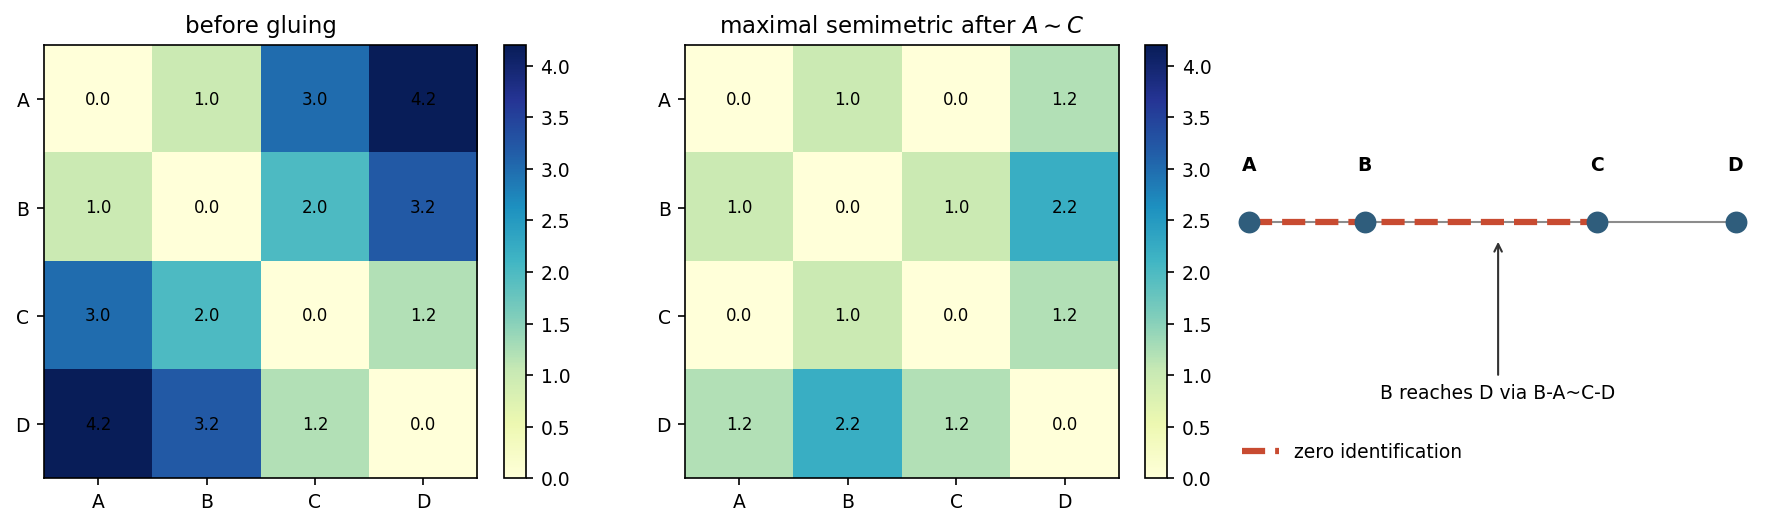

In [5]:
display_artifact(gluing_path)


The red zero edge is not merely a quotient of labels. It is an upper-bound constraint, and shortest-path closure propagates that constraint. This finite picture is the algorithmic shadow of the chapter's maximal-metric formulation of gluing.


## 3. Polyhedral Spaces, Metric Graphs, and Word Metrics

A polyhedral space is assembled from Euclidean pieces by isometries of faces, then metrized by the maximal metric compatible with those pieces. In dimension one this is a metric graph; for groups with finite generators the Cayley graph gives a word metric.

The next artifact juxtaposes three local links in a two-dimensional polyhedral space with a Cayley ball. Links are a compact way to remember the local cone model: an interior face point has a circular link of length $2\pi$, an edge point has a graph made from the adjacent faces, and a vertex can carry a more complicated graph.


In [6]:
fig = plt.figure(figsize=(12, 7), constrained_layout=True)
gs = fig.add_gridspec(2, 3)

ax0 = fig.add_subplot(gs[0, 0])
square = np.array([[0,0],[1,0],[1,1],[0,1]])
ax0.add_patch(Polygon(square, closed=True, facecolor="#e9f3e4", edgecolor="#355c35", lw=1.5))
ax0.annotate("", xy=(1.02,0.5), xytext=(1.35,0.5), arrowprops=dict(arrowstyle="->", color="#b24a3a"))
ax0.annotate("", xy=(-0.02,0.5), xytext=(-0.35,0.5), arrowprops=dict(arrowstyle="->", color="#b24a3a"))
ax0.annotate("", xy=(0.5,1.02), xytext=(0.5,1.35), arrowprops=dict(arrowstyle="->", color="#345da7"))
ax0.annotate("", xy=(0.5,-0.02), xytext=(0.5,-0.35), arrowprops=dict(arrowstyle="->", color="#345da7"))
ax0.text(0.5,0.5,"flat torus\nfrom edge gluings",ha="center",va="center")
ax0.set_title("face isometries as gluing data")
ax0.set_aspect("equal")
ax0.set_xlim(-.45,1.45); ax0.set_ylim(-.45,1.45); ax0.axis("off")

ax1 = fig.add_subplot(gs[0, 1])
theta = np.linspace(0, 2*np.pi, 240)
ax1.plot(np.cos(theta), np.sin(theta), color="#2f5d7c")
ax1.text(0,0,"interior\nlink",ha="center",va="center")
ax1.set_title(r"face point: circle, length $2\pi$")
ax1.set_aspect("equal"); ax1.axis("off")

ax2 = fig.add_subplot(gs[0, 2])
for y, color in [(.35, "#d98c3f"), (0, "#666666"), (-.35, "#4c78a8")]:
    ax2.plot([-1,1],[y,y], lw=2, color=color)
ax2.scatter([-1,1],[0,0], s=60, color="#333333")
ax2.text(0,.58,"several $\pi$-segments\nbetween two directions",ha="center")
ax2.set_title("edge point: graph link")
ax2.set_xlim(-1.2,1.2); ax2.set_ylim(-.75,.95); ax2.axis("off")

ax3 = fig.add_subplot(gs[1, 0])
angles_vertex = np.deg2rad([0, 55, 130, 205, 285, 360])
colors = ["#f2c572", "#9cc7c5", "#d6a1c1", "#a5b56d", "#e58b72"]
for a,b,c in zip(angles_vertex[:-1], angles_vertex[1:], colors):
    wedge = np.array([[0,0], [np.cos(a), np.sin(a)], [np.cos(b), np.sin(b)]])
    ax3.add_patch(Polygon(wedge, closed=True, facecolor=c, edgecolor="white", alpha=.95))
ax3.scatter([0],[0], s=80, color="#222222")
ax3.text(0,-.22,"vertex",ha="center",color="white",fontsize=8)
ax3.set_title("vertex: cone over its link")
ax3.set_aspect("equal"); ax3.axis("off")

ax4 = fig.add_subplot(gs[1, 1:])
G = nx.Graph()
radius = 3
nodes = [(i,j) for i in range(-radius, radius+1) for j in range(-radius, radius+1) if abs(i)+abs(j) <= radius]
G.add_nodes_from(nodes)
for i,j in nodes:
    for di,dj in [(1,0),(0,1)]:
        if (i+di,j+dj) in G:
            G.add_edge((i,j),(i+di,j+dj))
pos = {n:n for n in G.nodes}
word_len = {n: abs(n[0])+abs(n[1]) for n in G.nodes}
nx.draw_networkx_edges(G, pos, ax=ax4, edge_color="#b8b8b8", width=1)
nx.draw_networkx_nodes(G, pos, ax=ax4, node_size=80, node_color=[word_len[n] for n in G.nodes], cmap="viridis")
for n in [(0,0),(1,0),(0,1),(-1,0),(0,-1)]:
    ax4.text(n[0], n[1]+.12, str(n), ha="center", fontsize=7)
ax4.set_title(r"word ball in $\mathbb{Z}^2$: Cayley graph metric")
ax4.set_aspect("equal"); ax4.axis("off")

poly_path = FIG_DIR / "polyhedral-links-and-word-ball.png"
save_matplotlib(fig, poly_path)
plt.close(fig)

checks["artifacts"]["polyhedral-links-and-word-ball"] = rel(poly_path)
checks["invariants"]["polyhedral_graphs"] = {
    "cayley_ball_radius": radius,
    "cayley_ball_vertex_count": G.number_of_nodes(),
    "cayley_ball_edge_count": G.number_of_edges(),
    "sample_word_distance_2_1": abs(2) + abs(1),
    "face_link_total_angle": float(2 * math.pi),
}
checks["invariants"]["polyhedral_graphs"]


<>:27: SyntaxWarning: invalid escape sequence '\p'
<>:27: SyntaxWarning: invalid escape sequence '\p'
C:\Users\rahul\AppData\Local\Temp\ipykernel_38772\3977295443.py:27: SyntaxWarning: invalid escape sequence '\p'
  ax2.text(0,.58,"several $\pi$-segments\nbetween two directions",ha="center")


{'cayley_ball_radius': 3,
 'cayley_ball_vertex_count': 25,
 'cayley_ball_edge_count': 36,
 'sample_word_distance_2_1': 3,
 'face_link_total_angle': 6.283185307179586}

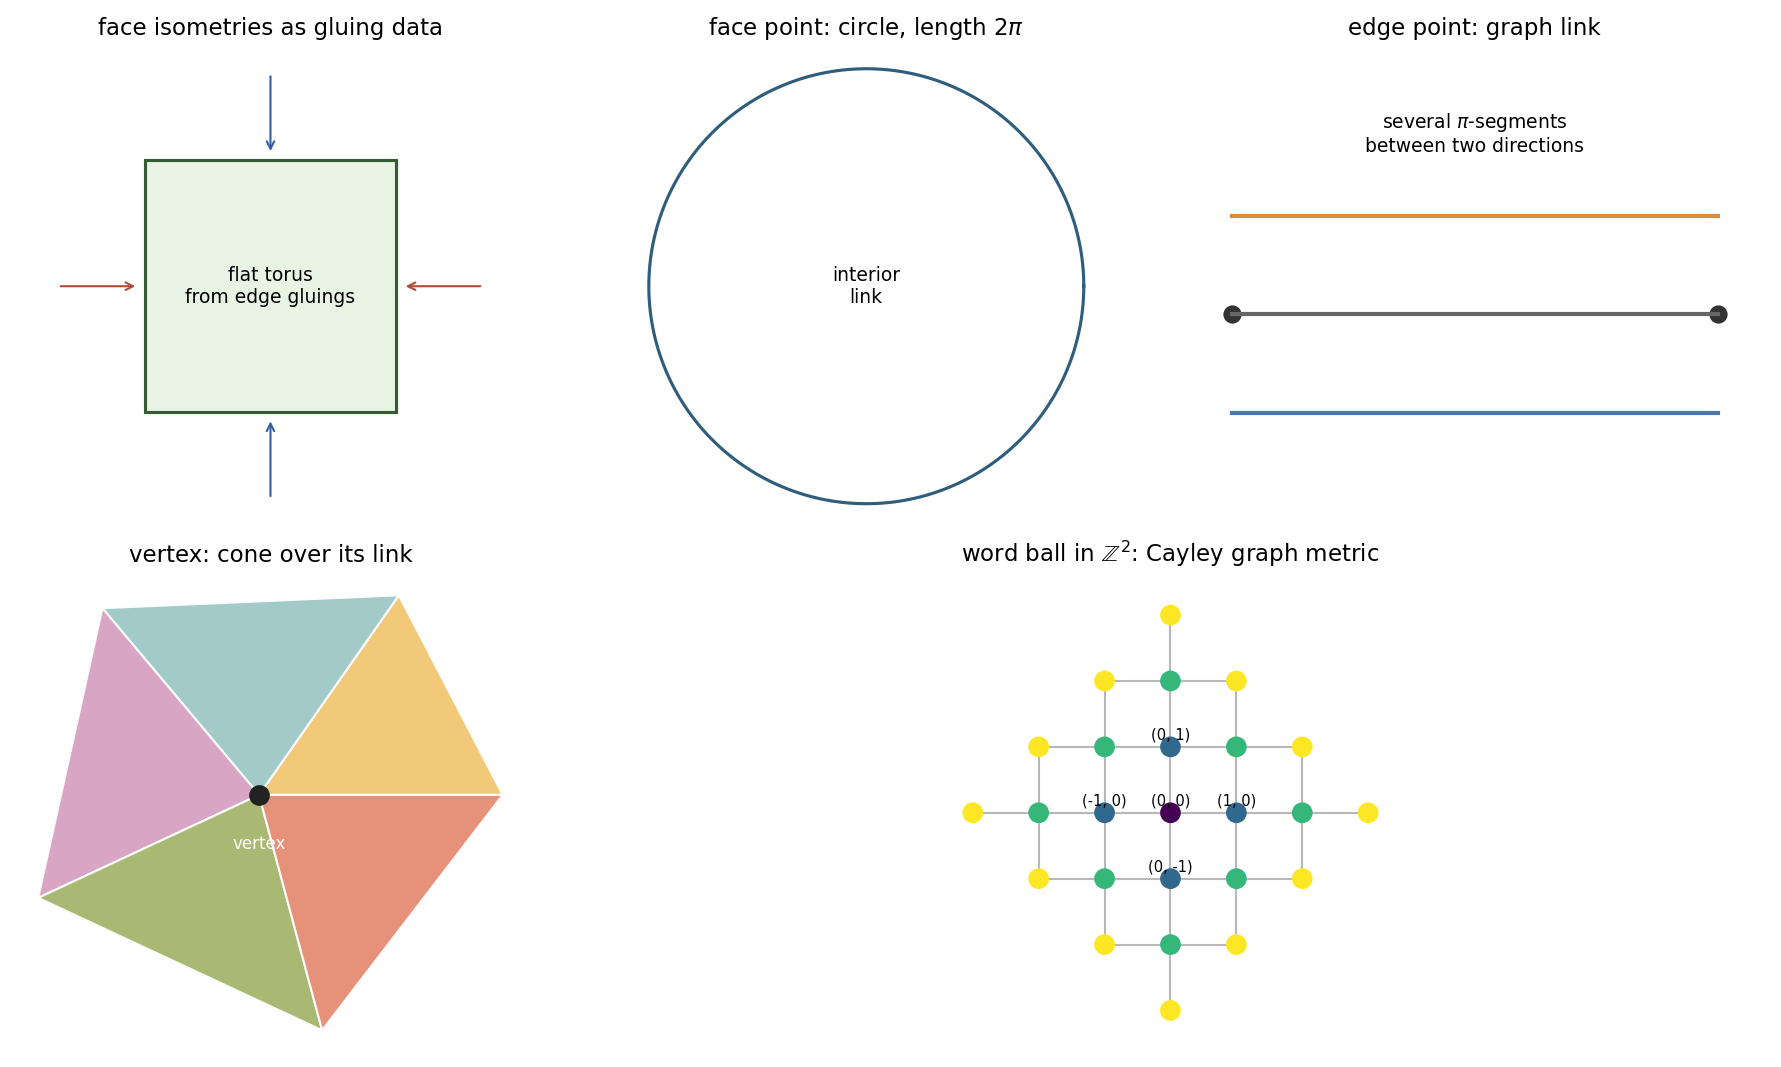

In [7]:
display_artifact(poly_path)


The Cayley graph panel is a metric graph with every edge length one. Its vertex distance is the word metric: the least number of generator moves needed to transform one group element into another. The link panels anticipate Section 3.6.20: small balls in a two-dimensional polyhedral space are cones over graph links.


## 4. Quotients, Local Isometries, and Coverings

For an isometric group action, quotient distance between orbits can be computed by minimizing distance over representatives. When the action is free and properly separated, the projection behaves locally like an isometry and, topologically, like a covering map. When a nontrivial group element fixes a point, the quotient can acquire a singular point.

The diagram below compares a translation quotient (locally regular) with a reflection/rotation quotient (fixed-point behavior). It also shows a truncated cover of a circle: every small evenly covered arc has separate copies upstairs.


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(12.5, 4), constrained_layout=True)

# Translation quotient on a grid.
ax = axes[0]
for i in range(-1, 3):
    ax.plot([i,i],[-1,2], color="#d0d0d0", lw=.8)
    ax.plot([-1,2],[i,i], color="#d0d0d0", lw=.8)
cell = np.array([[0,0],[1,0],[1,1],[0,1]])
ax.add_patch(Polygon(cell, closed=True, fill=False, edgecolor="#2f5d7c", lw=2))
ax.annotate("", xy=(1.02,.5), xytext=(1.35,.5), arrowprops=dict(arrowstyle="->", color="#b24a3a"))
ax.annotate("", xy=(-.02,.5), xytext=(-.35,.5), arrowprops=dict(arrowstyle="->", color="#b24a3a"))
ax.annotate("", xy=(.5,1.02), xytext=(.5,1.35), arrowprops=dict(arrowstyle="->", color="#345da7"))
ax.annotate("", xy=(.5,-.02), xytext=(.5,-.35), arrowprops=dict(arrowstyle="->", color="#345da7"))
ax.scatter([.2,1.2,.2],[.3,.3,1.3], color="#2f5d7c", s=35)
ax.set_title(r"$\mathbb{R}^2/\mathbb{Z}^2$: free translations")
ax.set_aspect("equal"); ax.set_xlim(-.6,1.6); ax.set_ylim(-.6,1.6); ax.axis("off")

# Fixed point quotient by half-turn.
ax = axes[1]
th = np.linspace(0, 2*np.pi, 240)
ax.plot(np.cos(th), np.sin(th), color="#cfcfcf")
for a in np.linspace(0, np.pi, 7, endpoint=False):
    ax.plot([0, np.cos(a)], [0, np.sin(a)], color="#6a8caf", lw=1)
    ax.plot([0, -np.cos(a)], [0, -np.sin(a)], color="#d7b26d", lw=1, alpha=.8)
ax.scatter([0],[0], s=70, color="#b24a3a")
ax.text(0, -.18, "fixed point", ha="center", color="#7d2f22")
ax.set_title(r"$\mathbb{R}^2/\{\pm id\}$: cone point")
ax.set_aspect("equal"); ax.axis("off")

# Cover of circle by line.
ax = axes[2]
xs = np.linspace(-2*np.pi, 2*np.pi, 500)
ax.plot(xs, np.zeros_like(xs), color="#2f5d7c", lw=2)
for k in range(-2,3):
    ax.scatter([2*np.pi*k],[0], color="#333333", s=25)
    ax.text(2*np.pi*k, .17, f"{k}", ha="center", fontsize=8)
for center in [-2*np.pi, 0, 2*np.pi]:
    ax.plot([center-.55, center+.55],[.08,.08], color="#d65f5f", lw=4, solid_capstyle="round")
circ = plt.Circle((0,-.9), .38, fill=False, color="#345da7", lw=2)
ax.add_patch(circ)
ax.plot([-.2,.2],[-.52,-.52], color="#d65f5f", lw=4, solid_capstyle="round")
ax.annotate("covering projection", xy=(0,-.48), xytext=(0,-.18), ha="center", arrowprops=dict(arrowstyle="->"))
ax.set_title(r"$\mathbb{R}\to S^1$: local sheets")
ax.set_xlim(-7.2,7.2); ax.set_ylim(-1.45,.45); ax.axis("off")

quot_path = FIG_DIR / "quotients-coverings-local-isometry.png"
save_matplotlib(fig, quot_path)
plt.close(fig)

# Numeric orbit-distance checks for a translation quotient of a flat torus.
def torus_distance(p, q, search=1):
    p = np.asarray(p); q = np.asarray(q)
    best = float("inf")
    best_shift = None
    for m, n in itertools.product(range(-search, search+1), repeat=2):
        cand = np.linalg.norm(p - (q + np.array([m, n], dtype=float)))
        if cand < best:
            best = cand; best_shift = (m, n)
    return best, best_shift

sample_d, sample_shift = torus_distance([0.1, 0.1], [0.92, 0.87], search=2)
checks["artifacts"]["quotients-coverings-local-isometry"] = rel(quot_path)
checks["invariants"]["quotient_covering"] = {
    "flat_torus_sample_orbit_distance": float(sample_d),
    "minimizing_integer_shift_for_sample": list(sample_shift),
    "translation_action_has_fixed_point": False,
    "half_turn_origin_fixed": True,
    "circle_cover_deck_step": float(2 * math.pi),
}
checks["invariants"]["quotient_covering"]


{'flat_torus_sample_orbit_distance': 0.2920616373302046,
 'minimizing_integer_shift_for_sample': [-1, -1],
 'translation_action_has_fixed_point': False,
 'half_turn_origin_fixed': True,
 'circle_cover_deck_step': 6.283185307179586}

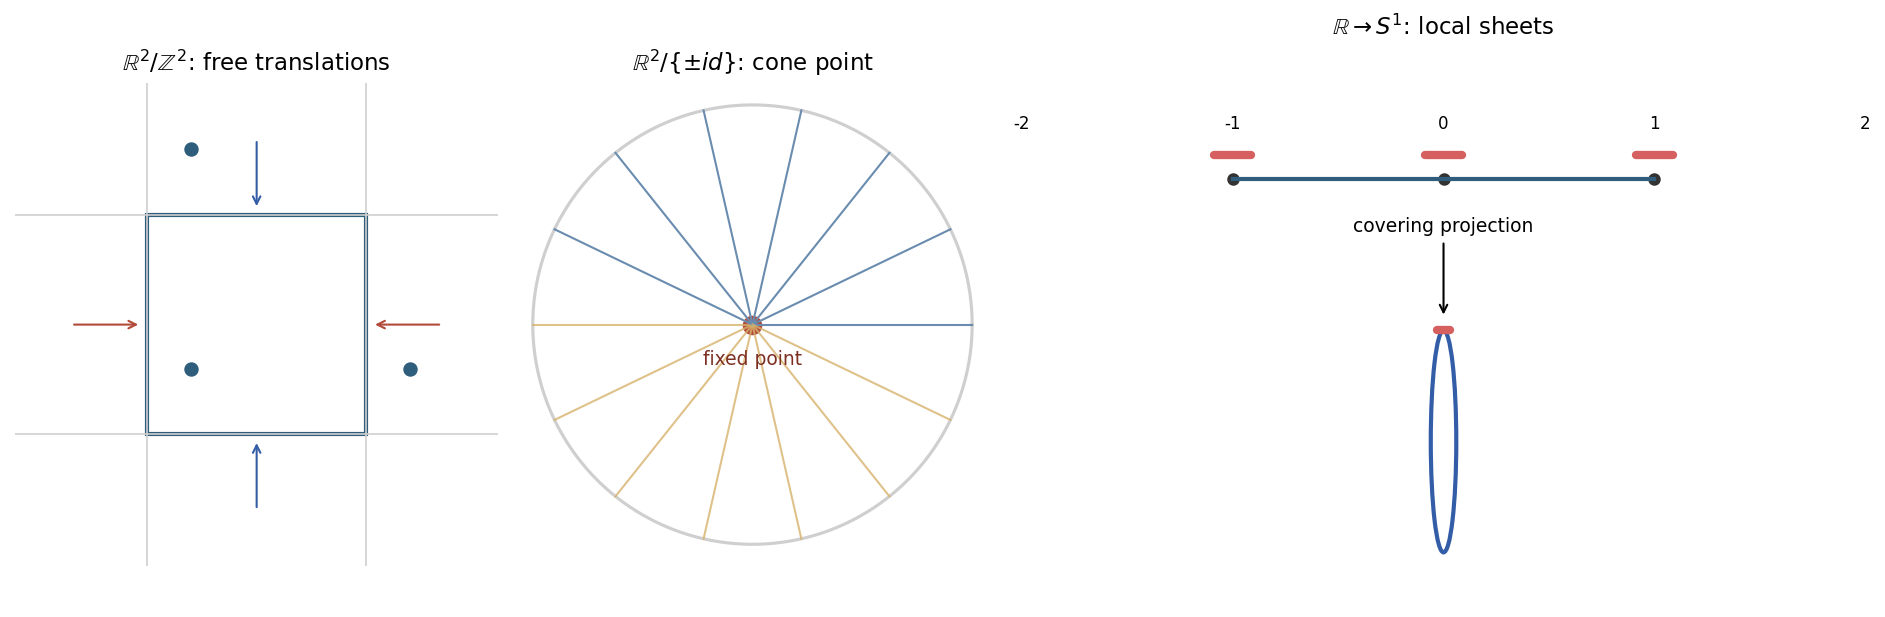

In [9]:
display_artifact(quot_path)


The flat torus panel is locally Euclidean because integer translations have no fixed points and keep small neighborhoods disjoint from their nontrivial translates. The cone panel marks the opposite failure mode: a fixed point survives as a singular orbit. The covering panel explains why lifted metrics and deck transformations appear naturally in the chapter.


## 5. Arcwise Isometries: Length Preservation Without Injectivity

Arcwise isometries preserve the length of every path. They need not preserve point distances, and they need not be one-to-one. This is why the chapter separates **isometry onto the image** from **isometric embedding** in the length-structure sense.

The pleat map below folds the real line. Its derivative has magnitude one on every linear piece, so every interval keeps its length as a path. But distinct points can land at the same target point.


In [10]:
def pleat(t):
    t = np.asarray(t)
    return np.where(t <= 0, t, np.where(t <= 1, -t, t - 2))

ts = np.linspace(-0.75, 1.75, 400)
fs = pleat(ts)
segments = [(-0.6, -0.1), (0.1, 0.8), (0.8, 1.4), (-0.5, 1.5)]
length_checks = []
for a, b in segments:
    sample = np.linspace(a, b, 1000)
    image_len = float(np.sum(np.abs(np.diff(pleat(sample)))))
    length_checks.append({"domain": [a, b], "domain_length": b-a, "image_path_length": image_len})

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), constrained_layout=True)
axes[0].plot(ts, fs, color="#2f5d7c", lw=2)
axes[0].axhline(0, color="#999999", lw=.8)
axes[0].axvline(0, color="#d65f5f", lw=.9, ls="--")
axes[0].axvline(1, color="#d65f5f", lw=.9, ls="--")
axes[0].set_title("pleat map with slopes +1, -1, +1")
axes[0].set_xlabel("source parameter")
axes[0].set_ylabel("target coordinate")
axes[0].grid(alpha=.25)

source_y = 0.25
image_y = -0.55
for a, b in [(-.6,0), (0,1), (1,1.6)]:
    axes[1].plot([a,b],[source_y,source_y], color="#2f5d7c", lw=5, solid_capstyle="round")
    axes[1].plot([pleat([a])[0], pleat([b])[0]],[image_y,image_y], color="#d98c3f", lw=5, solid_capstyle="round")
axes[1].scatter([0, 1, -1], [image_y]*3, color="#333333", s=25)
axes[1].text(.5, source_y+.15, "source line", ha="center")
axes[1].text(-.5, image_y-.25, "folded target path", ha="center")
axes[1].annotate("two source sides overlap", xy=(-.35,image_y), xytext=(.5,-.2), arrowprops=dict(arrowstyle="->"))
axes[1].set_xlim(-1.05,1.7); axes[1].set_ylim(-1,.6); axes[1].axis("off")

arc_path = FIG_DIR / "arcwise-isometry-pleat.png"
save_matplotlib(fig, arc_path)
plt.close(fig)

checks["artifacts"]["arcwise-isometry-pleat"] = rel(arc_path)
checks["invariants"]["arcwise_isometry"] = {
    "piecewise_abs_slopes": [1, 1, 1],
    "sample_interval_length_errors": [abs(row["domain_length"] - row["image_path_length"]) for row in length_checks],
    "not_injective_example": {"t0": -0.25, "t1": 0.25, "same_image": float(pleat([-0.25])[0]) == float(pleat([0.25])[0])},
}
checks["invariants"]["arcwise_isometry"]


{'piecewise_abs_slopes': [1, 1, 1],
 'sample_interval_length_errors': [5.551115123125783e-17,
  0.0,
  0.0,
  0.002002002002002179],
 'not_injective_example': {'t0': -0.25, 't1': 0.25, 'same_image': True}}

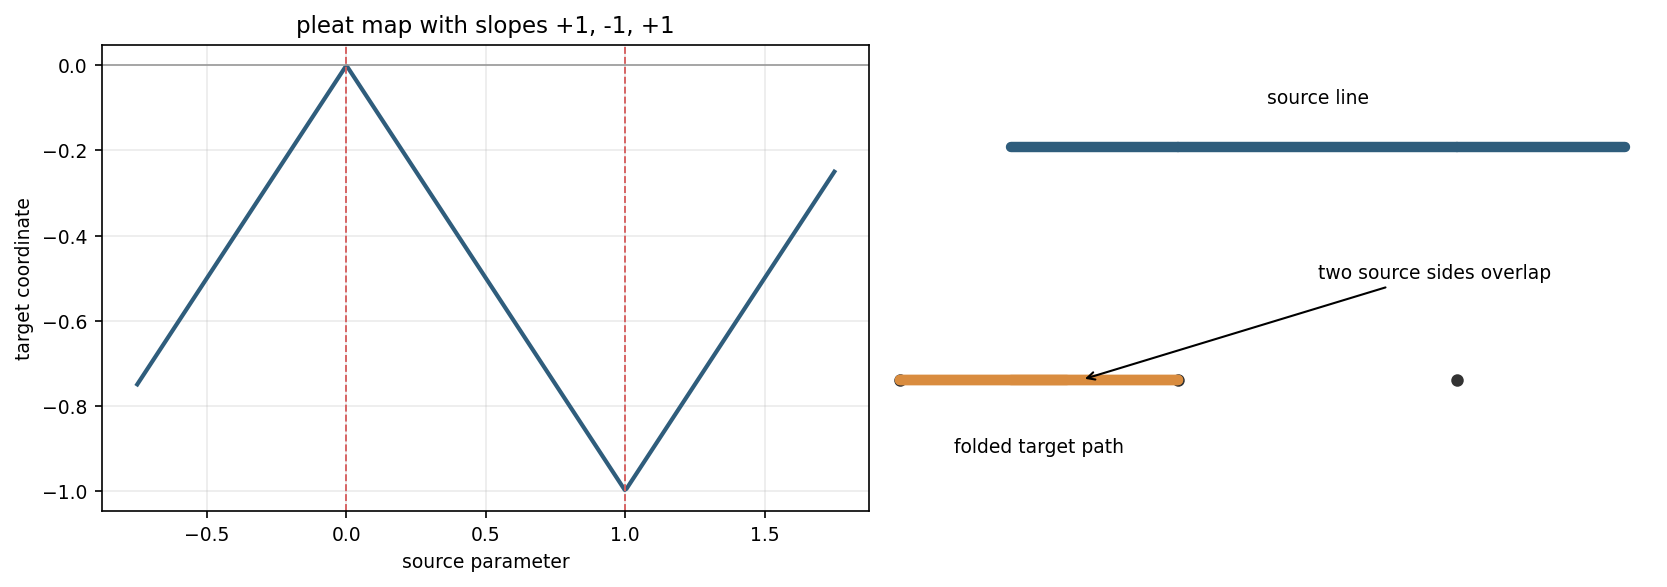

In [11]:
display_artifact(arc_path)


The graph is deliberately mundane: the point is not exotic topology but the distinction between preserving path length and preserving ambient restricted distances. This prepares the polyhedral folding theorem: a two-dimensional polyhedral metric may be induced by a highly folded map to the plane.


## 6. Products and Cones

Products and cones are the analytic constructions of the chapter. The product metric uses the Euclidean norm on factor distances,

$$d((x_1,y_1),(x_2,y_2))^2=d_X(x_1,x_2)^2+d_Y(y_1,y_2)^2,$$

so midpoints split into factor midpoints. The cone metric uses a law-of-cosines formula on radial coordinates, with base distances truncated at $\pi$ for large spaces.


In [12]:
# Product midpoint and cone-distance checks.
def product_distance(a, b):
    ax, ay = a; bx, by = b
    return math.hypot(ax - bx, ay - by)

def cone_distance(base_d, r, s):
    theta = min(base_d, math.pi)
    return math.sqrt(max(0.0, r*r + s*s - 2*r*s*math.cos(theta)))

z1 = (0.2, 0.3)
z2 = (3.4, 1.5)
zm = ((z1[0]+z2[0])/2, (z1[1]+z2[1])/2)
prod_mid = [product_distance(z1, z2), product_distance(z1, zm), product_distance(zm, z2)]

base_ds = np.linspace(0, 1.4 * math.pi, 200)
r, s = 1.0, 1.35
cone_ds = np.array([cone_distance(theta, r, s) for theta in base_ds])

fig = plt.figure(figsize=(12, 4.5), constrained_layout=True)
gs = fig.add_gridspec(1, 3)
ax = fig.add_subplot(gs[0, 0])
rect = np.array([[z1[0], z1[1]], [z2[0], z1[1]], [z2[0], z2[1]], [z1[0], z2[1]], [z1[0], z1[1]]])
ax.plot(rect[:,0], rect[:,1], color="#b8b8b8")
ax.plot([z1[0], z2[0]], [z1[1], z2[1]], color="#2f5d7c", lw=2, label="product geodesic")
ax.scatter([z1[0], z2[0], zm[0]], [z1[1], z2[1], zm[1]], color=["#333333", "#333333", "#d65f5f"], s=[35,35,50])
ax.text(zm[0], zm[1]+.13, "factor midpoint", ha="center")
ax.set_title("product midpoint splits by factors")
ax.set_aspect("equal"); ax.grid(alpha=.25); ax.legend(frameon=False)

ax = fig.add_subplot(gs[0, 1])
ax.plot(base_ds, cone_ds, color="#8b5a9f", lw=2)
ax.axvline(math.pi, color="#d65f5f", ls="--", lw=1)
ax.text(math.pi+.05, cone_ds.max()*.8, r"truncate at $\pi$", color="#9b3f35")
ax.set_xlabel("base distance")
ax.set_ylabel("cone distance")
ax.set_title("cone law of cosines with clipped angle")
ax.grid(alpha=.25)

ax = fig.add_subplot(gs[0, 2], projection="3d")
phi = np.linspace(0, 1.35*math.pi, 60)
rad = np.linspace(0, 1.4, 40)
Phi, R = np.meshgrid(phi, rad)
X = R*np.cos(Phi)
Y = R*np.sin(Phi)
Z = 0.55*R
ax.plot_surface(X, Y, Z, cmap="viridis", alpha=.82, linewidth=0, antialiased=True)
ax.plot([0,1.2],[0,0],[0,.66], color="#333333", lw=2)
ax.set_title("cone over a segment = sector-like surface")
ax.set_axis_off()

prod_cone_png = FIG_DIR / "product-cone-metrics.png"
save_matplotlib(fig, prod_cone_png)
plt.close(fig)

# Interactive Plotly lab.
u = np.linspace(0, 2*np.pi, 48)
v = np.linspace(-1.5, 1.5, 24)
U, V = np.meshgrid(u, v)
Xc = np.cos(U); Yc = np.sin(U); Zc = V
phi = np.linspace(0, 1.6*np.pi, 64)
rad = np.linspace(0, 1.7, 36)
Phi, R = np.meshgrid(phi, rad)
Xk = R*np.cos(Phi); Yk = R*np.sin(Phi); Zk = 0.65*R
fig_html = make_subplots(rows=1, cols=2, specs=[[{"type":"surface"},{"type":"surface"}]], subplot_titles=("Product R x S1", "Cone over an interval"))
fig_html.add_trace(go.Surface(x=Xc, y=Yc, z=Zc, colorscale="Blues", showscale=False, opacity=.92), row=1, col=1)
fig_html.add_trace(go.Surface(x=Xk, y=Yk, z=Zk, colorscale="Viridis", showscale=False, opacity=.92), row=1, col=2)
fig_html.update_layout(title="Chapter 3 product and cone inspection lab", height=520, margin=dict(l=0,r=0,t=60,b=0))
html_path = HTML_DIR / "product-cone-inspection-lab.html"
save_plotly_html(fig_html, html_path)

checks["artifacts"]["product-cone-metrics"] = rel(prod_cone_png)
checks["artifacts"]["product-cone-inspection-lab"] = rel(html_path)
checks["invariants"]["product_cone"] = {
    "product_distance": prod_mid[0],
    "midpoint_distance_left": prod_mid[1],
    "midpoint_distance_right": prod_mid[2],
    "midpoint_half_error": abs(prod_mid[1] - prod_mid[0]/2) + abs(prod_mid[2] - prod_mid[0]/2),
    "cone_distance_at_base_0": float(cone_ds[0]),
    "cone_distance_for_base_beyond_pi": float(cone_distance(1.3*math.pi, r, s)),
    "radial_path_via_origin_length": float(r + s),
}
checks["invariants"]["product_cone"]


{'product_distance': 3.4176014981270124,
 'midpoint_distance_left': 1.7088007490635064,
 'midpoint_distance_right': 1.7088007490635062,
 'midpoint_half_error': 2.220446049250313e-16,
 'cone_distance_at_base_0': 0.3500000000000001,
 'cone_distance_for_base_beyond_pi': 2.35,
 'radial_path_via_origin_length': 2.35}

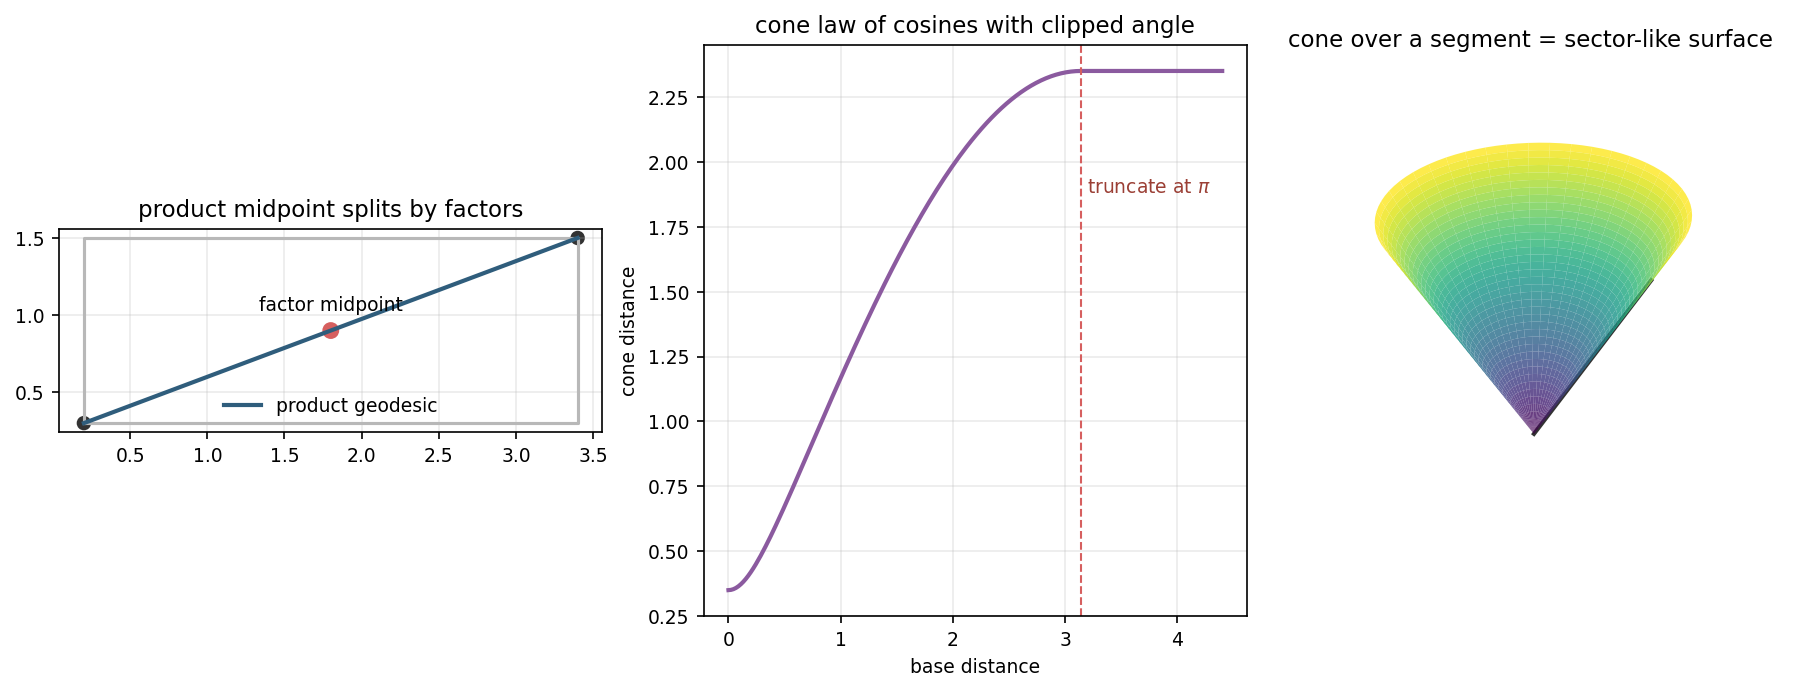

In [13]:
display_artifact(prod_cone_png)
display_artifact(html_path)


The product midpoint check mirrors the proof of the product proposition: if both factors are strictly intrinsic, factor midpoints combine into a product midpoint. The cone plot shows the two regimes: below $\pi$ the law of cosines sees the base distance, while at and beyond $\pi$ the shortest route goes through the apex and has length $r+s$.


## Applied Lab

Use the artifact set as a diagnostic bench. First, choose a pair in the gluing heatmap whose distance changed even though it was not declared equivalent. Then compare the translation quotient and half-turn quotient panels: identify which local neighborhoods project isometrically and which point fails because of a stabilizer. Finally, use the product/cone lab to explain why the cone distance switches to the radial route through the apex once the base separation reaches $\pi$.


## 7. Source Coverage and Invariant Summary

The notebook does not reproduce the source. Instead it covers each requested construction with an inspectable model:

- **3.1 locality, gluing, maximal metrics:** $d_\varepsilon$ and maximal semimetric closure.
- **3.2 polyhedral spaces:** face gluing, metric graph links, Cayley/word metric ball.
- **3.3 isometries and quotients:** orbit distance and fixed-point quotient behavior.
- **3.4 local isometries and coverings:** local sheets, deck-translation picture, free action criterion.
- **3.5 arcwise isometries:** pleat map preserving path length while folding.
- **3.6 products and cones:** product midpoint, cone law of cosines, product/cone HTML lab.

The final cell writes machine-checkable coverage and sanity records under `artifacts/chapter-03/checks/`.


In [14]:
storyboard = {
    "chapter_goal": "Build new length spaces while preserving metric invariants.",
    "visual_sequence": [
        "locality-epsilon-jumps",
        "gluing-maximal-semimetric",
        "polyhedral-links-and-word-ball",
        "quotients-coverings-local-isometry",
        "arcwise-isometry-pleat",
        "product-cone-metrics",
        "product-cone-inspection-lab"
    ],
    "checks": ["triangle inequality", "local agreement", "orbit distance", "arcwise length", "product midpoint", "cone truncation"],
}

coverage = {
    "3.1 Locality, Gluing and Maximal Metrics": [
        "locality-epsilon-jumps.png",
        "gluing-maximal-semimetric.png",
    ],
    "3.2 Polyhedral Spaces": [
        "polyhedral-links-and-word-ball.png",
    ],
    "3.3 Isometries and Quotients": [
        "quotients-coverings-local-isometry.png",
    ],
    "3.4 Local Isometries and Coverings": [
        "quotients-coverings-local-isometry.png",
    ],
    "3.5 Arcwise Isometries": [
        "arcwise-isometry-pleat.png",
    ],
    "3.6 Products and Cones": [
        "product-cone-metrics.png",
        "product-cone-inspection-lab.html",
    ],
}
checks["coverage"] = coverage

# Artifact and numerical sanity.
artifact_paths = [BOOK_ROOT / path for path in checks["artifacts"].values()]
artifact_status = []
for path in artifact_paths:
    status = {"path": rel(path), "exists": path.exists(), "bytes": path.stat().st_size if path.exists() else 0}
    if path.suffix.lower() == ".png" and path.exists():
        status["nonblank"] = image_nonblank(path)
    artifact_status.append(status)

checks["artifact_status"] = artifact_status
checks["final_assertions"] = {
    "all_artifacts_exist_and_nonempty": all(row["exists"] and row["bytes"] > 200 for row in artifact_status),
    "all_pngs_nonblank": all(row.get("nonblank", True) for row in artifact_status),
    "gluing_triangle_ok": checks["invariants"]["gluing_maximal_semimetric"]["triangle_violations"] == 0,
    "locality_local_agreement_ok": checks["invariants"]["locality_epsilon"]["local_agreement_max_abs_error"] < 1e-9,
    "product_midpoint_ok": checks["invariants"]["product_cone"]["midpoint_half_error"] < 1e-9,
    "arcwise_sample_lengths_ok": max(checks["invariants"]["arcwise_isometry"]["sample_interval_length_errors"]) < 1e-2,
}

storyboard_path = save_json(CHECK_DIR / "visual-storyboard.json", storyboard)
coverage_path = save_json(CHECK_DIR / "source-coverage.json", checks["coverage"])
invariants_path = save_json(CHECK_DIR / "construction-invariants.json", checks["invariants"])
final_sanity = checks
final_path = save_json(CHECK_DIR / "final-sanity.json", final_sanity)

assert checks["final_assertions"]["all_artifacts_exist_and_nonempty"]
assert checks["final_assertions"]["all_pngs_nonblank"]
assert checks["final_assertions"]["gluing_triangle_ok"]
assert checks["final_assertions"]["locality_local_agreement_ok"]
assert checks["final_assertions"]["product_midpoint_ok"]
assert checks["final_assertions"]["arcwise_sample_lengths_ok"]

{"storyboard": rel(storyboard_path), "coverage": rel(coverage_path), "invariants": rel(invariants_path), "sanity": rel(final_path), "assertions": checks["final_assertions"]}


{'storyboard': 'artifacts/chapter-03/checks/visual-storyboard.json',
 'coverage': 'artifacts/chapter-03/checks/source-coverage.json',
 'invariants': 'artifacts/chapter-03/checks/construction-invariants.json',
 'sanity': 'artifacts/chapter-03/checks/final-sanity.json',
 'assertions': {'all_artifacts_exist_and_nonempty': True,
  'all_pngs_nonblank': True,
  'gluing_triangle_ok': True,
  'locality_local_agreement_ok': True,
  'product_midpoint_ok': True,
  'arcwise_sample_lengths_ok': True}}

## Takeaways

Chapter 3 is a toolkit for building length spaces without losing control of distance.

1. Local length data can determine an intrinsic metric, but non-intrinsic metrics can imitate it locally and diverge globally.
2. Gluing is not just topology: the quotient metric is the maximal semimetric compatible with the requested identifications and the triangle inequality.
3. Polyhedral spaces and metric graphs make gluing combinatorial, while links record the local cone model.
4. Quotients by free isometric actions behave locally like the original space; fixed points explain singular quotient points.
5. Coverings lift length metrics and turn deck transformations into isometries.
6. Arcwise isometries preserve length structures even when they fold heavily.
7. Products and cones are metric formulas with geometric content: factor geodesics in products and law-of-cosines sectors in cones.
